In [13]:
import pandas as pd
import numpy as np
import os
import sys
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from functools import  partial
parent_dir = os.path.dirname(os.environ["GTE_DIR"].replace("Glaciation_time_estimator",""))
GTE_DIR=os.environ["GTE_DIR"]
sys.path.insert(0, parent_dir)
from glaciation_time_estimator.data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from glaciation_time_estimator.auxiliary_func.config_reader import read_config

In [14]:
config = read_config(
    os.path.join(GTE_DIR,'configs/2021_tracking/01_01.yaml'))
analyze_year=True
year=2022
global global_rmse
global_rmse = config["Global_sqrt_mse"]
ice_cont_crit_frac = 0.05
# classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]

In [ ]:
if os.uname()[1]=="n2o":
    combined_cloud_df = pd.read_parquet("/net/n2o/wolke_scratch/dnikolo/Final_results/2022_all.parquet")
if os.uname()[1][:3]=="eu-":
    combined_cloud_df = pd.read_parquet(f"/cluster/work/climate/dnikolo/Cloud_analysis/full_years/{year}_all.parquet")
combined_cloud_df=combined_cloud_df[~combined_cloud_df.is_large_pix_cloud]
combined_cloud_df = combined_cloud_df[(combined_cloud_df.avg_lat >30) | (combined_cloud_df.avg_lat<-30)]

In [ ]:
combined_cloud_df.keys()

Index(['is_large_pix_cloud', 'is_cot_valid_cloud', 'is_ctp_valid_cloud',
       'is_liq', 'is_mix', 'is_ice', 'max_water_frac', 'max_ice_fraction',
       'avg_size[km]', 'max_size[km]', 'min_size[km]', 'avg_size[px]',
       'max_size[px]', 'min_size[px]', 'track_start_time', 'track_length',
       'avg_cot', 'avg_ctp', 'glaciation_start_time', 'glaciation_end_time',
       'avg_lat', 'avg_lon', 'start_ice_fraction', 'end_ice_fraction',
       'ice_frac_hist', 'cot_hist', 'cot_nan_frac_hist', 'ctp_hist',
       'ctp_nan_frac_hist', 'lat_hist', 'lon_hist', 'size_hist_km', 'min_temp',
       'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]', 'Radius [km]',
       'Level', 'Optical Thickness', 'Cloud type', 'Season'],
      dtype='object')

In [ ]:
combined_cloud_df["avg_ctp"].quantile(0.99)

869.7008453369141

In [ ]:
combined_cloud_df["avg_ctp"].quantile(0.01)

330.8840790499174

In [ ]:
combined_cloud_df.keys()

Index(['is_large_pix_cloud', 'is_cot_valid_cloud', 'is_ctp_valid_cloud',
       'is_liq', 'is_mix', 'is_ice', 'max_water_frac', 'max_ice_fraction',
       'avg_size[km]', 'max_size[km]', 'min_size[km]', 'avg_size[px]',
       'max_size[px]', 'min_size[px]', 'track_start_time', 'track_length',
       'avg_cot', 'avg_ctp', 'glaciation_start_time', 'glaciation_end_time',
       'avg_lat', 'avg_lon', 'start_ice_fraction', 'end_ice_fraction',
       'ice_frac_hist', 'cot_hist', 'cot_nan_frac_hist', 'ctp_hist',
       'ctp_nan_frac_hist', 'lat_hist', 'lon_hist', 'size_hist_km', 'min_temp',
       'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]', 'Radius [km]',
       'Level', 'Optical Thickness', 'Cloud type', 'Season'],
      dtype='object')

In [ ]:
sample=combined_cloud_df
# sample=sample[(sample.avg_lat >30) | (sample.avg_lat<-30)]
#Create meshgrid for x,y

In [ ]:
combined_cloud_df.is_large_pix_cloud.sum()/len(combined_cloud_df)
len(sample)/len(combined_cloud_df)

1.0

Map of cloud all fragment positions

In [ ]:
from  matplotlib.colors import LinearSegmentedColormap
# Total number of colors
n_colors = 256

# Define custom sections
yellow_to_red_fraction = 0.35  # Yellow-to-red ends at 4°C
bordeaux_to_purple_fraction = 0.35  # Bordeaux-to-purple starts at 4°C and ends at 6°C
purple_to_pink_fraction = 0.3  # Purple-to-pink for the highest extremes (6°C to 8°C)

# Create an empty array for the colormap
colors = np.zeros((n_colors, 4))  # RGBA array, initialized with zeros

# Define yellow-to-red section (normalized 0 to 4°C)
yellow_to_red_end = int(yellow_to_red_fraction * n_colors)
for i in range(0, yellow_to_red_end):
    t = i / yellow_to_red_end
    colors[i, :3] = (1 - t) * np.array([1, 1, 0.8]) + t * np.array([1, 0.5, 0.2])  # Adjusted yellow to red gradient
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Define red-to-bordeaux-to-purple section (normalized 4 to 6°C)
bordeaux_to_purple_start = yellow_to_red_end
bordeaux_to_purple_end = bordeaux_to_purple_start + int(bordeaux_to_purple_fraction * n_colors)
for i in range(bordeaux_to_purple_start, bordeaux_to_purple_end):
    t = (i - bordeaux_to_purple_start) / (bordeaux_to_purple_end - bordeaux_to_purple_start)
    colors[i, :3] = (1 - t) * np.array([1, 0.5, 0.2]) + t * np.array([0.5, 0, 0.5])  # Red to purple
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Define purple-to-pink section (normalized 6 to 8°C)
purple_to_pink_start = bordeaux_to_purple_end
for i in range(purple_to_pink_start, n_colors):
    t = (i - purple_to_pink_start) / (n_colors - purple_to_pink_start)
    colors[i, :3] = (1 - t) * np.array([0.5, 0, 0.5]) + t * np.array([1, 0.75, 0.8])  # Purple to pink
    colors[i, 3] = 1  # Set alpha channel to fully opaque

# Create the custom colormap
difference_plot_cmap = LinearSegmentedColormap.from_list("difference_plot_cmap", colors)

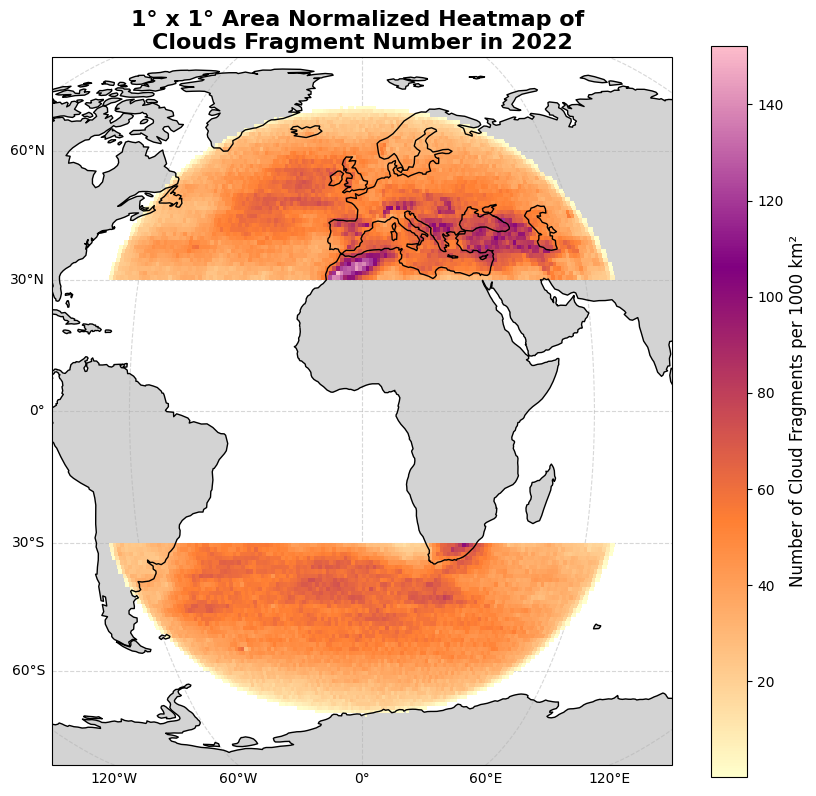

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Example DataFrame 'sample' ----
# sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})

# 1. Define bin edges for 1° increments
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)

# 2. Compute the 2D histogram
heatmap, lon_edges, lat_edges = np.histogram2d(
    sample['avg_lon'],
    sample['avg_lat'],
    bins=[lon_bins, lat_bins]
)

# 3. Mask zero-count cells so they're transparent
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
heatmap /=area_factors
heatmap *=1000
masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# 4. Set up the figure and Cartopy axes — use Robinson now
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# Often for Robinson, setting a global extent is a nice choice:
# ax.set_global()
ax.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# 5. Add a simple land background (light gray), behind everything
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# 6. Add lat/lon gridlines *behind* the heatmap
# Note: For certain projections like Robinson, labeling can sometimes be problematic.
gl = ax.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
# area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# 7. Plot the heatmap on top (higher z-order than grid)
mesh = ax.pcolormesh(
    lon_edges,
    lat_edges,
    masked_heatmap.T,    # transpose to align axes
    transform=ccrs.PlateCarree(),
    shading='nearest',
    cmap=difference_plot_cmap,
    zorder=2
)

# 8. Add coastlines *above* the heatmap
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# (No country borders added, per your requirement)

# 9. Add colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical',shrink=0.95)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=12)

ax.set_title('1° x 1° Area Normalized Heatmap of \nClouds Fragment Number in 2022', fontsize=16,fontweight='bold' )
plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined.png"),dpi=400,bbox_inches='tight')
plt.show()


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import matplotlib
# # ---- Example DataFrame 'sample' ----
# # sample = pd.DataFrame({'avg_lon': [...], 'avg_lat': [...]})

# # 1. Define bin edges for 1° increments
# lon_bins = np.arange(-80, 82, 1)
# lat_bins = np.arange(-80, 82, 1)

# # 2. Compute the 2D histogram
# heatmap, lon_edges, lat_edges = np.histogram2d(
#     sample['avg_lon'],
#     sample['avg_lat'],
#     bins=[lon_bins, lat_bins]
# )

# # 3. Mask zero-count cells so they're transparent
# masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

# # 4. Set up the figure and Cartopy axes — use Robinson now
# fig = plt.figure(figsize=(10, 10))
# ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# # Often for Robinson, setting a global extent is a nice choice:
# # ax.set_global()
# ax.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
# # 5. Add a simple land background (light gray), behind everything
# ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

# # 6. Add lat/lon gridlines *behind* the heatmap
# # Note: For certain projections like Robinson, labeling can sometimes be problematic.
# gl = ax.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
# gl.top_labels = False
# gl.right_labels = False

# # 7. Plot the heatmap on top (higher z-order than grid)
# mesh = ax.pcolormesh(
#     lon_edges,
#     lat_edges,
#     masked_heatmap.T,    # transpose to align axes
#     transform=ccrs.PlateCarree(),
#     shading='nearest',
#     cmap="plasma",
#     zorder=2,
#     norm=matplotlib.colors.LogNorm()
# )

# # 8. Add coastlines *above* the heatmap
# ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# # (No country borders added, per your requirement)

# # 9. Add colorbar
# cbar = plt.colorbar(mesh, ax=ax, orientation='vertical',shrink=0.95)
# cbar.set_label('Number of Cloud Fragments',fontsize=12)

# ax.set_title('1° x 1° Heatmap of \nClouds Fragment Number in 2022', fontsize=16,fontweight='bold' )
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_combined_log.png"),dpi=400)
# plt.show()

Map of cloud fragment positions by temp range

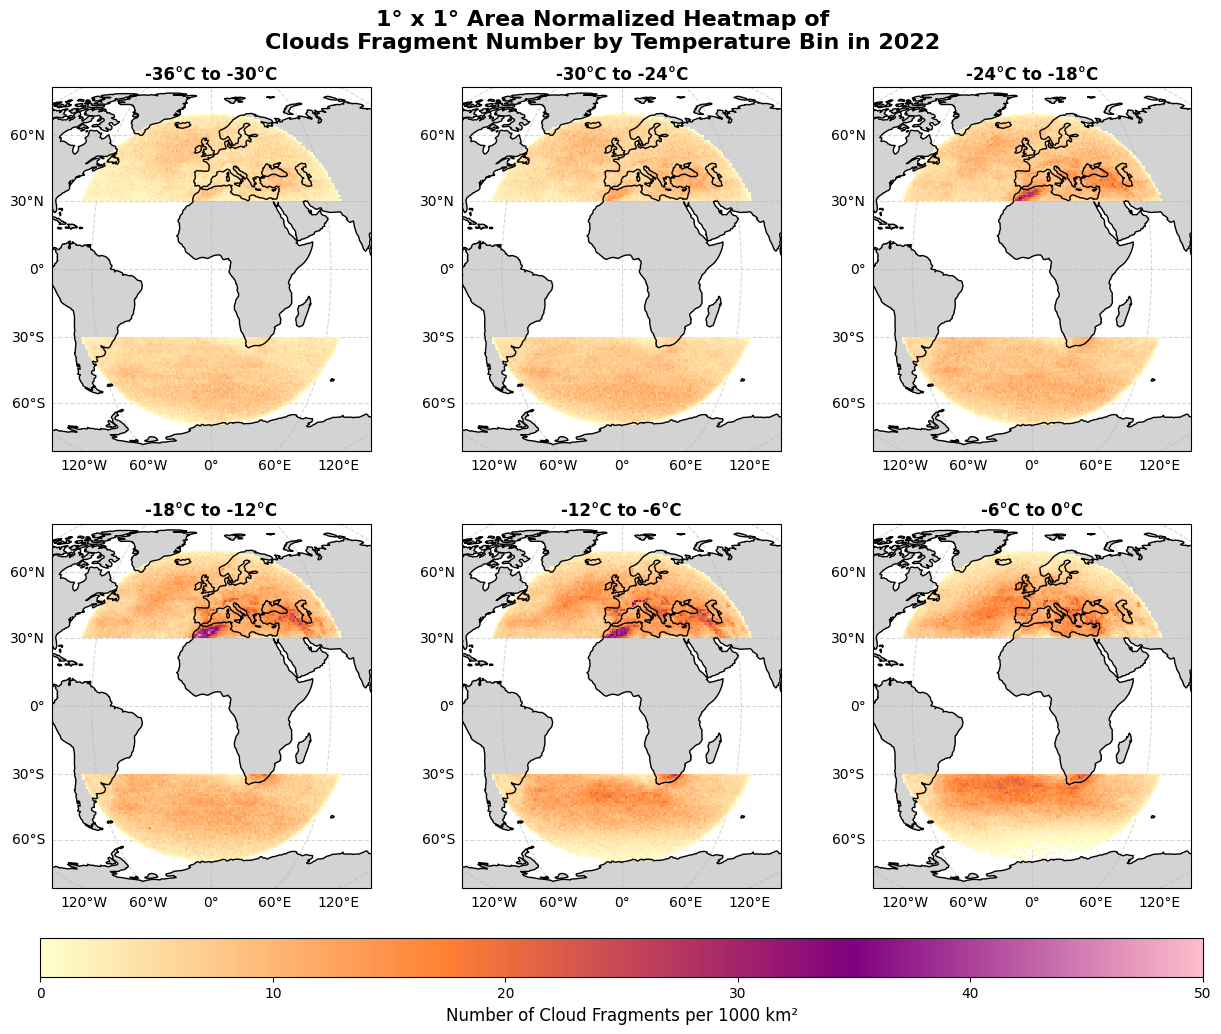

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ------------------------------------------------------------------------------
# Assumes 'sample' is a DataFrame with columns:
#     - 'avg_lon' : float (longitude)
#     - 'avg_lat' : float (latitude)
#     - 'min_temp': int or float (the lower bound of a temperature range)
# There are 6 unique values in 'min_temp'.
# The corresponding 'max_temp' is implicitly min_temp + 6
# ------------------------------------------------------------------------------

# 1) Identify the unique temperature ranges
unique_min_temps = sorted(sample['min_temp'].unique())

# 2) Optionally, figure out a global max count so all subplots share the same scale
all_max_counts = []
for t in unique_min_temps:
    subset = sample[sample['min_temp'] == t]
    heatmap_temp, _, _ = np.histogram2d(
        subset['avg_lon'], subset['avg_lat'],
        bins=[np.arange(-80, 82, 1), np.arange(-80, 82, 1)]
    )
    all_max_counts.append(heatmap_temp.max())

global_vmax = max(all_max_counts)

# 3) Create a grid of subplots with Robinson projection (3 rows, 2 columns)
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(12, 10),  # can adjust as needed
    subplot_kw=dict(projection=ccrs.Robinson())
)
axes = axes.ravel()

# 4) Loop over each unique min_temp
plots = []
lon_bins = np.arange(-80, 82, 1)
lat_bins = np.arange(-80, 82, 1)
area_factors = np.tile(abs(np.cos(lat_bins[:-1]/180*np.pi)).T,(161,1))* 111*111
# print(area_factors[:,1])
custom_map_colormap = sns.color_palette("plasma", as_cmap=True)
# sns.color_palette("YlOrBr", as_cmap=True)
for i, t in enumerate(unique_min_temps):
    ax = axes[i]
    
    # Optionally limit the view to [-80, 80] lat/lon, even in Robinson:
    ax.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
    
    # Subset data
    subset = sample[sample['min_temp'] == t]

    # 2D histogram
    heatmap, lon_edges, lat_edges = np.histogram2d(
        subset['avg_lon'], subset['avg_lat'],
        bins=[lon_bins, lat_bins]
    )
    # print(heatmap.shape)
    # heatmap[80:100,:]=0
    heatmap /=area_factors
    heatmap*=1000
    # print(heatmap.shape)
    masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

    # Add background land
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # pcolormesh
    mesh = ax.pcolormesh(
        lon_edges, 
        lat_edges, 
        masked_heatmap.T,
        transform=ccrs.PlateCarree(),
        shading='nearest',
        cmap=difference_plot_cmap,
        vmin=0,
        vmax=50,
        zorder=2
    )
    plots.append(mesh)

    # Coastlines
    ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)
    ax.xticks()
    ax.set_title(f'{t}°C to {t+6}°C',fontsize=12, fontweight='bold')

# 5) Single colorbar
cbar = fig.colorbar(
    plots[-1],
    ax=axes.ravel().tolist(),
    orientation='horizontal',
    shrink=1,
    pad=0.05,
    # fraction=0.02,   # smaller fraction -> narrower colorbar
    aspect=30        # larger aspect -> taller (and thus relatively narrower) colorbar
)
plt.xticks(fontsize=12)
cbar.set_label('Number of Cloud Fragments per 1000 km²',fontsize=12)

plt.suptitle('1° x 1° Area Normalized Heatmap of\nClouds Fragment Number by Temperature Bin in 2022', fontsize=16, fontweight='bold', y=0.94)
plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_by_temp_range.png"),dpi=400,bbox_inches='tight')

plt.show()


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # ------------------------------------------------------------------------------
# # Assumes 'sample' is a DataFrame with columns:
# #     - 'avg_lon' : float (longitude)
# #     - 'avg_lat' : float (latitude)
# #     - 'min_temp': int or float (the lower bound of a temperature range)
# # There are 6 unique values in 'min_temp'.
# # The corresponding 'max_temp' is implicitly min_temp + 6
# # ------------------------------------------------------------------------------

# # 1) Identify the unique temperature ranges
# unique_min_temps = sorted(sample['min_temp'].unique())

# # 2) Optionally, figure out a global max count so all subplots share the same scale
# all_max_counts = []
# for t in unique_min_temps:
#     subset = sample[sample['min_temp'] == t]
#     heatmap_temp, _, _ = np.histogram2d(
#         subset['avg_lon'], subset['avg_lat'],
#         bins=[np.arange(-80, 82, 1), np.arange(-80, 82, 1)]
#     )
#     all_max_counts.append(heatmap_temp.max())

# global_vmax = max(all_max_counts)

# # 3) Create a grid of subplots with Robinson projection (3 rows, 2 columns)
# fig, axes = plt.subplots(
#     nrows=3, ncols=2,
#     figsize=(10, 15),  # can adjust as needed
#     subplot_kw=dict(projection=ccrs.Robinson())
# )
# axes = axes.ravel()

# # 4) Loop over each unique min_temp
# plots = []
# lon_bins = np.arange(-80, 82, 1)
# lat_bins = np.arange(-80, 82, 1)
# custom_map_colormap = sns.color_palette("plasma", as_cmap=True)
# # sns.color_palette("YlOrBr", as_cmap=True)
# for i, t in enumerate(unique_min_temps):
#     ax = axes[i]
    
#     # Optionally limit the view to [-80, 80] lat/lon, even in Robinson:
#     ax.set_extent([-80, 80, -90, 90], crs=ccrs.PlateCarree())
    
#     # Subset data
#     subset = sample[sample['min_temp'] == t]

#     # 2D histogram
#     heatmap, lon_edges, lat_edges = np.histogram2d(
#         subset['avg_lon'], subset['avg_lat'],
#         bins=[lon_bins, lat_bins]
#     )
#     masked_heatmap = np.ma.masked_where(heatmap == 0, heatmap)

#     # Add background land
#     ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

#     # Gridlines
#     gl = ax.gridlines(draw_labels=True, zorder=1, linestyle='--', alpha=0.5)
#     gl.top_labels = False
#     gl.right_labels = False

#     # pcolormesh
#     mesh = ax.pcolormesh(
#         lon_edges, 
#         lat_edges, 
#         masked_heatmap.T,
#         transform=ccrs.PlateCarree(),
#         shading='nearest',
#         cmap="plasma",
#         zorder=2,
#         norm=matplotlib.colors.LogNorm(vmin=1,vmax=global_vmax)
#     )
#     plots.append(mesh)

#     # Coastlines
#     ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

#     ax.set_title(f'{t}°C to {t+6}°C',fontsize=12, fontweight='bold')

# # 5) Single colorbar
# cbar = fig.colorbar(
#     plots[-1],
#     ax=axes.ravel().tolist(),
#     orientation='vertical',
#     shrink=0.95,
#     pad=0.05,
#     # fraction=0.02,   # smaller fraction -> narrower colorbar
#     aspect=50        # larger aspect -> taller (and thus relatively narrower) colorbar
# )
# cbar.set_label('Number of Cloud Fragments',fontsize=12)

# plt.suptitle('1°x1° Heatmaps of Cloud Fragment Number\n by Temperature Bin in 2022', fontsize=16, fontweight='bold', y=0.94)
# plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Cloud_number_map_by_temp_range_log.png"),dpi=400)
# plt.show()

Chord lengh cascade of all clouds

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


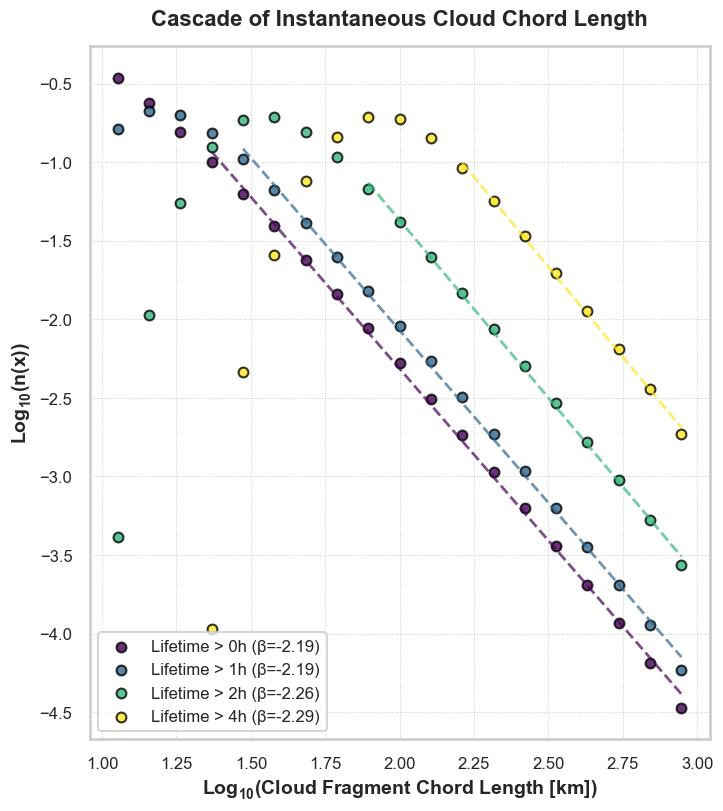

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

exponents = np.linspace(1, 3, 20)
centers = exponents[:-1] + (exponents[1:] - exponents[:-1]) / 2
bins = np.power(10, exponents)
bin_width=bins[1:]-bins[:-1]
lifetime_thresholds = [0, 1, 2, 4]

# Set up figure
fig, ax = plt.subplots(figsize=(12, 16))

# Use a colormap for better differentiation
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(lifetime_thresholds)))

for i, lifetime_thresh in enumerate(lifetime_thresholds):
    # Normalize cloud radius
    combined_cloud_df["norm_radius"] = combined_cloud_df["Radius [km]"] * combined_cloud_df["Lifetime [h]"]*np.pi/8

    
    # Bin data
    #(combined_cloud_df["Cloud type"]=="Altostratus" ) & (combined_cloud_df["Cloud type"]!="" )&
    bin_counts = pd.cut(
        combined_cloud_df[ (combined_cloud_df["Lifetime [h]"] > lifetime_thresh)
        ]["norm_radius"], bins
    ).value_counts(sort=False)/bin_width
    
    # Normalize bin counts
    new_df = pd.DataFrame({"bin_counts": bin_counts, "center": centers})
    new_df["bin_counts"] = new_df["bin_counts"] / new_df["bin_counts"].sum()

    # Fit line to the tail of the distribution
    fit_df = new_df[new_df["bin_counts"].idxmax():].iloc[3:]
    coef = np.polyfit(x=fit_df["center"], y=np.log10(fit_df["bin_counts"]), deg=1)
    poly1d_fn = np.poly1d(coef)
    R2 = r2_score(np.log10(fit_df["bin_counts"]), poly1d_fn(fit_df["center"]))
    # Scatter plot with better markers
    # ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f}, $R^2$={R2:.02f})', 
    #            color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f})', 
               color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    
    # Fitted line with better visibility
    ax.plot(fit_df["center"], poly1d_fn(fit_df["center"]), linestyle="--", linewidth=2, alpha=0.7, color=viridis_colors[i])

# Improve axes formatting
# ax.set_xscale("log")
# ax.set_ylim(-7,-2)
ax.set_title("Cascade of Instantaneous Cloud Chord Length", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("$\mathregular{Log_{10}}$(Cloud Fragment Chord Length [km])", fontsize=14, fontweight='bold')
ax.set_ylabel(u"$\mathregular{Log_{10}}$(n(x))", fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc="lower left")

# Add grid with minor ticks
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Chord_length_log_scale_cascade.png"),dpi=400, bbox_inches='tight')
# Show plot
plt.show()


Chord length Straticumulus

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


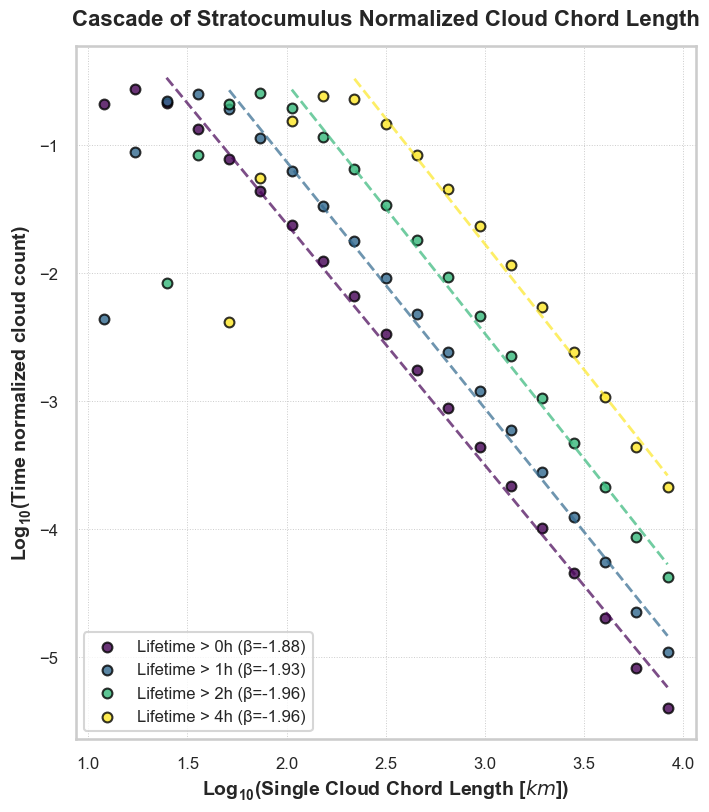

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

exponents = np.linspace(1, 4, 20)
centers = exponents[:-1] + (exponents[1:] - exponents[:-1]) / 2
bins = np.power(10, exponents)
bin_width=bins[1:]-bins[:-1]
lifetime_thresholds = [0, 1, 2, 4]

# Set up figure
fig, ax = plt.subplots(figsize=(12, 16))

# Use a colormap for better differentiation
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(lifetime_thresholds)))

for i, lifetime_thresh in enumerate(lifetime_thresholds):
    # Normalize cloud radius
    combined_cloud_df["norm_radius"] = combined_cloud_df["Radius [km]"] * combined_cloud_df["Lifetime [h]"]*np.pi/4

    # Bin data
    bin_counts = pd.cut(
        combined_cloud_df[(combined_cloud_df["Cloud type"]=="Stratocumulus") & (combined_cloud_df["Lifetime [h]"] > lifetime_thresh)
        ]["norm_radius"], bins
    ).value_counts(sort=False)/bin_width
    
    # Normalize bin counts
    new_df = pd.DataFrame({"bin_counts": bin_counts, "center": centers})
    new_df["bin_counts"] = new_df["bin_counts"] / new_df["bin_counts"].sum()

    # Fit line to the tail of the distribution
    fit_df = new_df[new_df["bin_counts"].idxmax():].iloc[1:]
    coef = np.polyfit(x=fit_df["center"], y=np.log10(fit_df["bin_counts"]), deg=1)
    poly1d_fn = np.poly1d(coef)
    R2 = r2_score(np.log10(fit_df["bin_counts"]), poly1d_fn(fit_df["center"]))
    # Scatter plot with better markers
    # ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f}, $R^2$={R2:.02f})', 
    #            color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f})', 
               color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    
    # Fitted line with better visibility
    ax.plot(fit_df["center"], poly1d_fn(fit_df["center"]), linestyle="--", linewidth=2, alpha=0.7, color=viridis_colors[i])

# Improve axes formatting
# ax.set_xscale("log")
# ax.set_ylim(-7,-2)
ax.set_title("Cascade of Stratocumulus Normalized Cloud Chord Length", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("$\mathregular{Log_{10}}$(Single Cloud Chord Length [$km$])", fontsize=14, fontweight='bold')
ax.set_ylabel("$\mathregular{Log_{10}}$(Time normalized cloud count)", fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc="lower left")

# Add grid with minor ticks
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Statocumulus_chord_length_log_scale_cascade.png"),dpi=400, bbox_inches='tight')
# Show plot
plt.show()

Chord length cascade Altostratus

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


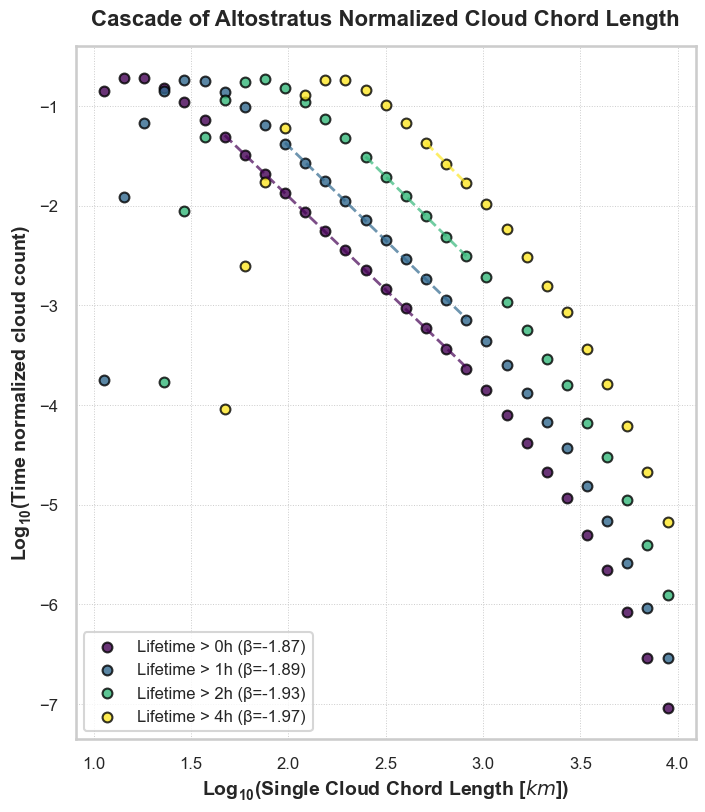

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

exponents = np.linspace(1, 4, 30)
centers = exponents[:-1] + (exponents[1:] - exponents[:-1]) / 2
bins = np.power(10, exponents)
bin_width=bins[1:]-bins[:-1]
lifetime_thresholds = [0, 1, 2, 4]

# Set up figure
fig, ax = plt.subplots(figsize=(12, 16))

# Use a colormap for better differentiation
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(lifetime_thresholds)))

for i, lifetime_thresh in enumerate(lifetime_thresholds):
    # Normalize cloud radius
    combined_cloud_df["norm_radius"] = combined_cloud_df["Radius [km]"] * combined_cloud_df["Lifetime [h]"]*np.pi/4

    # Bin data
    bin_counts = pd.cut(
        combined_cloud_df[(combined_cloud_df["Cloud type"]=="Altostratus") & (combined_cloud_df["Lifetime [h]"] > lifetime_thresh)
        ]["norm_radius"], bins
    ).value_counts(sort=False)/bin_width
    
    # Normalize bin counts
    new_df = pd.DataFrame({"bin_counts": bin_counts, "center": centers})
    new_df["bin_counts"] = new_df["bin_counts"] / new_df["bin_counts"].sum()

    # Fit line to the tail of the distribution
    fit_df = new_df[new_df["bin_counts"].idxmax():].iloc[5:-10]
    coef = np.polyfit(x=fit_df["center"], y=np.log10(fit_df["bin_counts"]), deg=1)
    poly1d_fn = np.poly1d(coef)
    R2 = r2_score(np.log10(fit_df["bin_counts"]), poly1d_fn(fit_df["center"]))
    # Scatter plot with better markers
    # ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f}, $R^2$={R2:.02f})', 
    #            color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f})', 
               color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    
    # Fitted line with better visibility
    ax.plot(fit_df["center"], poly1d_fn(fit_df["center"]), linestyle="--", linewidth=2, alpha=0.7, color=viridis_colors[i])

# Improve axes formatting
# ax.set_xscale("log")
# ax.set_ylim(-7,-2)
ax.set_title("Cascade of Altostratus Normalized Cloud Chord Length", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("$\mathregular{Log_{10}}$(Single Cloud Chord Length [$km$])", fontsize=14, fontweight='bold')
ax.set_ylabel("$\mathregular{Log_{10}}$(Time normalized cloud count)", fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc="lower left")

# Add grid with minor ticks
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Altocumulus_chord_length_log_scale_cascade.png"),dpi=400, bbox_inches='tight')
# Show plot
plt.show()

Cloud area cascade

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


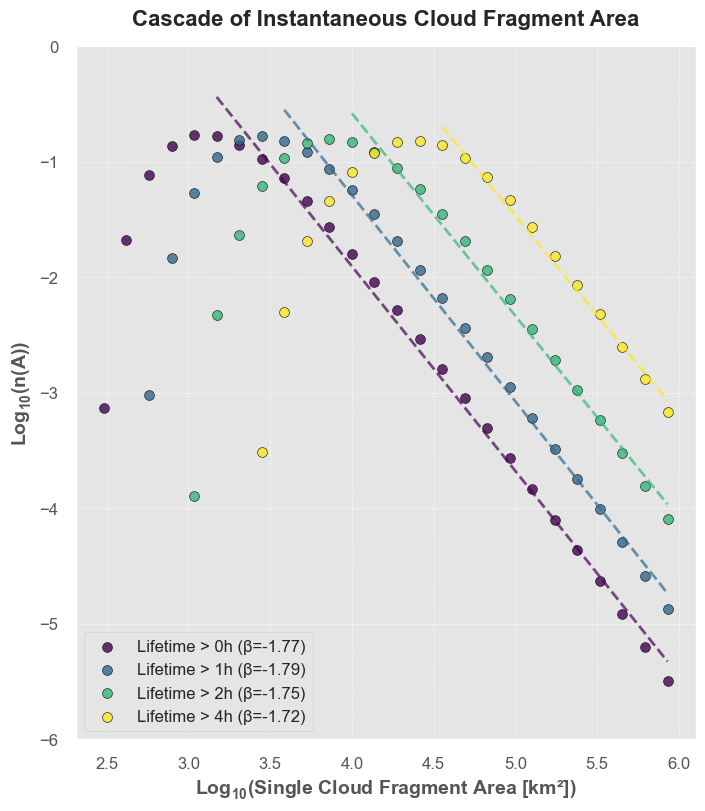

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Use a modern style
plt.style.use("ggplot")

# Define the exponents and bins
exponents = np.linspace(2, 6, 30)
centers = exponents[:-1] + (exponents[1:] - exponents[:-1]) / 2
bins = np.power(10, exponents)
bin_width=bins[1:]-bins[:-1]
lifetime_thresholds = [0 ,1, 2, 4]

# Set up figure
fig, ax = plt.subplots(figsize=(12, 16))

# Use a colormap for better differentiation
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(lifetime_thresholds)))

for i, lifetime_thresh in enumerate(lifetime_thresholds):
    # Normalize cloud area
    combined_cloud_df["norm_area"] = combined_cloud_df["avg_size[km]"] * combined_cloud_df["Lifetime [h]"]

    # Bin data
    bin_counts = pd.cut(
        combined_cloud_df[ (combined_cloud_df["Lifetime [h]"] > lifetime_thresh)]["norm_area"], bins
    ).value_counts(sort=False)/bin_width#*3000*800/((3000-np.power(10,centers/2)/18-1)*(800-np.power(10,centers/2)/18-1))
    
    # Normalize bin counts
    new_df = pd.DataFrame({"bin_counts": bin_counts, "center": centers})
    new_df["bin_counts"] = new_df["bin_counts"] / new_df["bin_counts"].sum()
    
    # Fit line to the tail of the distribution
    fit_df = new_df[new_df["bin_counts"].idxmax():].iloc[1:]
    coef = np.polyfit(x=fit_df["center"], y=np.log10(fit_df["bin_counts"]), deg=1)
    poly1d_fn = np.poly1d(coef)
    
    # # Scatter plot with better markers
    # ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f})', 
    #            color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    R2 = r2_score(np.log10(fit_df["bin_counts"]), poly1d_fn(fit_df["center"]))
    # Scatter plot with better markers
    # ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f}, $R^2$={R2:.02f})', 
    #            color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    ax.scatter(new_df["center"], np.log10(new_df["bin_counts"]), label=f'Lifetime > {lifetime_thresh}h (β={coef[0]:.02f})', 
               color=viridis_colors[i], s=50, alpha=0.8, edgecolors="black")
    # Fitted line with better visibility
    ax.plot(fit_df["center"], poly1d_fn(fit_df["center"]), linestyle="--", linewidth=2, alpha=0.7, color=viridis_colors[i])

# Improve axes formatting
# ax.set_xscale("log")
ax.set_ylim(-6,0)
ax.set_xlabel("$\mathregular{Log_{10}}$(Single Cloud Fragment Area [km²])", fontsize=14, fontweight='bold')
ax.set_ylabel("$\mathregular{Log_{10}}$(n(A))", fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc="lower left")
ax.set_title("Cascade of Instantaneous Cloud Fragment Area", fontsize=16, fontweight='bold', pad=15)
# Add grid with minor ticks
ax.grid(True, which="both", linestyle=":", linewidth=0.7)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(GTE_DIR,"Result_graphs/Avg_area_log_scale_cascade.png"),dpi=400, bbox_inches='tight')
# Show plot
plt.show()

Cloud fragment number by fragment type

<Figure size 600x1000 with 0 Axes>

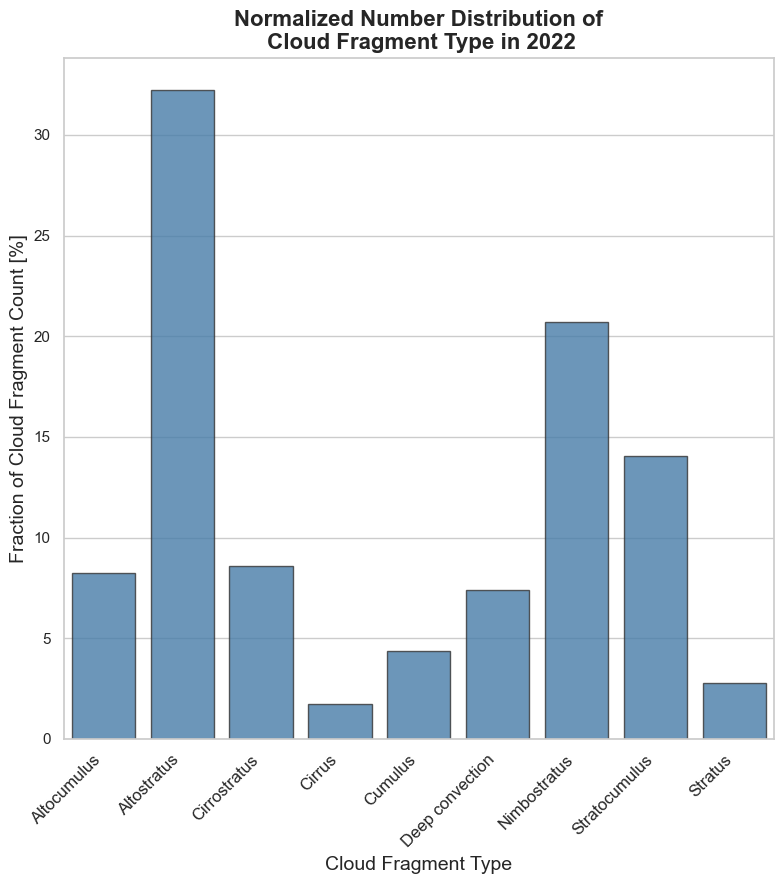

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the overall theme and style
sns.set_theme(style="whitegrid")

# Increase figure size for better clarity
plt.figure(figsize=(12, 16))
fig, ax = plt.subplots(figsize=(12, 16))
# Create the histogram with a pastel palette and subtle edge viridis_colors
combined_cloud_df["norm_area"] = combined_cloud_df["avg_size[km]"] * combined_cloud_df["Lifetime [h]"]
total_area_per_clloud_type=combined_cloud_df.groupby("Cloud type")["norm_area"].count()
total_area_per_clloud_type/=total_area_per_clloud_type.sum()/100

ax = sns.barplot(
    x = total_area_per_clloud_type.index,
    y = total_area_per_clloud_type,
    color=classifiacation_palette[1],      # You can customize the color as desired
    edgecolor=".2",        # Adds a slight border for clarity
    alpha=0.8
)
# ax.bar_label(ax.containers[0], fontsize=10)
# Customize title and axis labels
ax.set_title("Normalized Number Distribution of\n Cloud Fragment Type in 2022", fontsize=16, fontweight='bold')
ax.set_xlabel("Cloud Fragment Type", fontsize=14)
ax.set_ylabel(u"Fraction of Cloud Fragment Count [%]", fontsize=14)
# ax.set_ylim(0,0.7e5)
# Adjust x-ticks: rotate, adjust font size, and align to the left
plt.xticks(fontsize=12, rotation=45, ha='right')

# Improve layout spacing
plt.tight_layout()
plt.savefig(os.path.join(GTE_DIR, "Result_graphs/Type_number_distribution.png"),dpi=400, bbox_inches='tight')

Instantaneous Cloud cover by fragment type

Cloud type
Altocumulus         1.986801
Altostratus        24.806444
Cirrostratus        2.336965
Cirrus              0.210767
Cumulus             3.474437
Deep convection     2.662395
Nimbostratus       15.787420
Stratocumulus      43.609329
Stratus             5.125442
Name: norm_area, dtype: float64


<Figure size 600x1000 with 0 Axes>

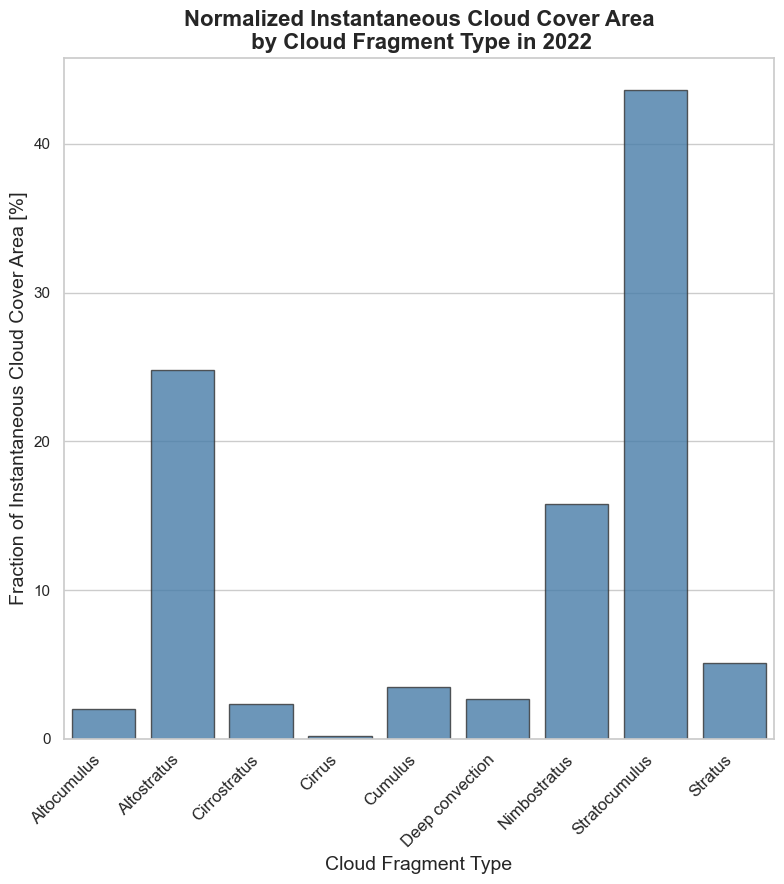

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the overall theme and style
sns.set_theme(style="whitegrid")

# Increase figure size for better clarity
plt.figure(figsize=(12, 18))
fig, ax = plt.subplots(figsize=(12, 18))
# Create the histogram with a pastel palette and subtle edge viridis_colors
combined_cloud_df["norm_area"] = combined_cloud_df["avg_size[km]"] * combined_cloud_df["Lifetime [h]"]
total_area_per_clloud_type=combined_cloud_df.groupby("Cloud type")["norm_area"].sum()
total_area_per_clloud_type/=total_area_per_clloud_type.sum()/100
print(total_area_per_clloud_type)
ax = sns.barplot(
    x = total_area_per_clloud_type.index,
    y = total_area_per_clloud_type,
    color=classifiacation_palette[1],      # You can customize the color as desired
    edgecolor=".2",        # Adds a slight border for clarity
    alpha=0.8
)
# ax.bar_label(ax.containers[0], fontsize=10)
# Customize title and axis labels
ax.set_title("Normalized Instantaneous Cloud Cover Area\n by Cloud Fragment Type in 2022", fontsize=16, fontweight='bold')
ax.set_xlabel("Cloud Fragment Type", fontsize=14)
ax.set_ylabel(u"Fraction of Instantaneous Cloud Cover Area [%]", fontsize=14)
# ax.set_ylim(0,0.7e5)
# Adjust x-ticks: rotate, adjust font size, and align to the left
plt.xticks(fontsize=12, rotation=45, ha='right')

# Improve layout spacing
plt.tight_layout()
plt.savefig(os.path.join(GTE_DIR, "Result_graphs/Type_area_distribution.png"),dpi=400, bbox_inches='tight')
plt.show()

Measurement of cloud cover by type in the overall dataset

In [ ]:
#!/usr/bin/env python3
import xarray as xr


# File paths for the normalized datasets
np_file = "/wolke_scratch/dnikolo/CLAAS_Data/Cloud_cover_by_class/np/time_mean.nc"
sp_file = "/wolke_scratch/dnikolo/CLAAS_Data/Cloud_cover_by_class/sp/time_mean.nc"

# Open the datasets
ds_np = xr.open_dataset(np_file)
ds_sp = xr.open_dataset(sp_file)

# Select only values where georef_offset_corrected equals 1
ds_np_sel = ds_np.sel(georef_offset_corrected=1)
ds_sp_sel = ds_sp.sel(georef_offset_corrected=1)

# Identify variables ending with '_frac'
frac_vars = [var for var in ds_np_sel.data_vars if var.endswith('_frac')]

# Compute the element-wise mean of each _frac variable between the two datasets
mean_vars = {}
for var in frac_vars:
    mean_vars[var] = (ds_np_sel[var][0,0,0] + ds_sp_sel[var][0,0,0]) / 2.0
summed_cover=0
# For demonstration, print the mean values for each variable
for var, data in mean_vars.items():
    print(f"Mean of {var}:")
    print(data.values)
    print()
    summed_cover+=data.values
print(summed_cover)


Mean of ci_frac:
0.05377701669931412

Mean of cs_frac:
0.03987327218055725

Mean of dc_frac:
0.02722463384270668

Mean of ac_frac:
0.18060147762298584

Mean of as_frac:
0.1485716700553894

Mean of ns_frac:
0.09201761335134506

Mean of cu_frac:
0.19557496905326843

Mean of sc_frac:
0.19786638021469116

Mean of st_frac:
0.06381966173648834

0.9993266947567463


In [ ]:
for cloud_type in combined_cloud_df["Cloud type"].unique():
    print()

{'ci_frac': <xarray.DataArray 'ci_frac' (time: 1, y: 1, x: 1)> Size: 4B
 array([[[0.05883551]]], dtype=float32)
 Coordinates:
   * time                     (time) datetime64[ns] 8B 2022-01-08T11:52:30
   * x                        (x) float64 8B 0.0
   * y                        (y) float64 8B 0.0
     georef_offset_corrected  float64 8B 1.0,
 'cs_frac': <xarray.DataArray 'cs_frac' (time: 1, y: 1, x: 1)> Size: 4B
 array([[[0.04897743]]], dtype=float32)
 Coordinates:
   * time                     (time) datetime64[ns] 8B 2022-01-08T11:52:30
   * x                        (x) float64 8B 0.0
   * y                        (y) float64 8B 0.0
     georef_offset_corrected  float64 8B 1.0,
 'dc_frac': <xarray.DataArray 'dc_frac' (time: 1, y: 1, x: 1)> Size: 4B
 array([[[0.0326251]]], dtype=float32)
 Coordinates:
   * time                     (time) datetime64[ns] 8B 2022-01-08T11:52:30
   * x                        (x) float64 8B 0.0
   * y                        (y) float64 8B 0.0
     georef_

Boxplot cloud of cloud area by cloud type

<Figure size 1000x600 with 0 Axes>

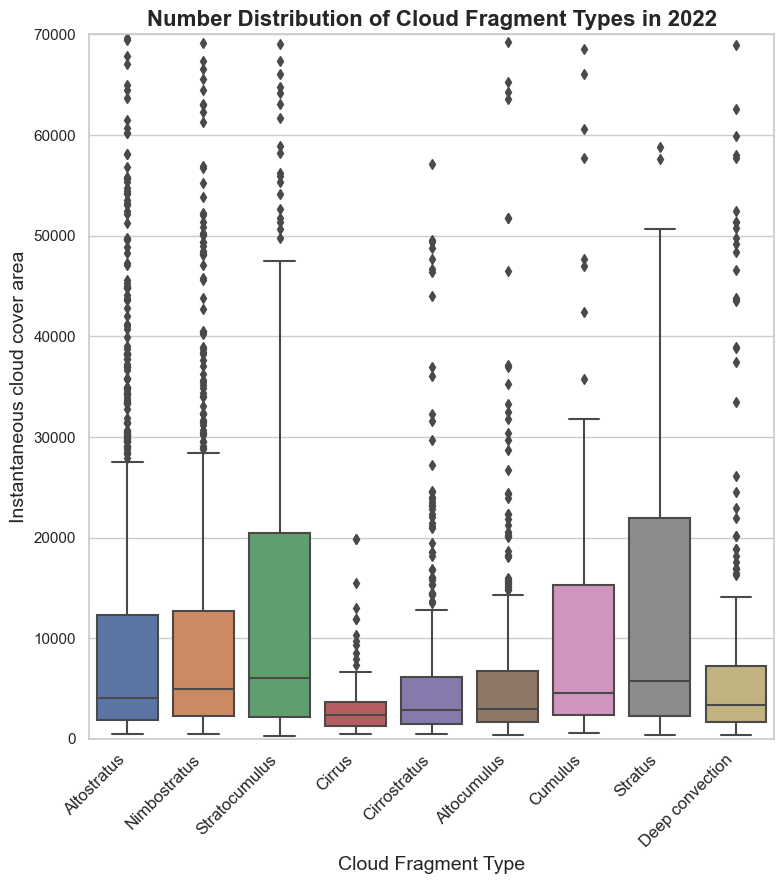

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the overall theme and style
sns.set_theme(style="whitegrid")

# Increase figure size for better clarity
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(figsize=(8, 9))
# Create the histogram with a pastel palette and subtle edge viridis_colors

# ax = sns.barplot(
#     x = combined_cloud_df.groupby("Cloud type")["norm_area"].sum().index,
#     y = combined_cloud_df.groupby("Cloud type")["norm_area"].sum(),
#     color=viridis_colors[0],      # You can customize the color as desired
#     edgecolor=".2"        # Adds a slight border for clarity
# )
combined_cloud_df["norm_area"] = combined_cloud_df["avg_size[km]"] * combined_cloud_df["Lifetime [h]"]
sns.boxplot(data=combined_cloud_df.sample(10000),ax=ax, x="Cloud type", y="norm_area")

# Customize title and axis labels
ax.set_title("Number Distribution of Cloud Fragment Types in 2022", fontsize=16, fontweight='bold')
ax.set_xlabel("Cloud Fragment Type", fontsize=14)
ax.set_ylabel("Instantaneous cloud cover area", fontsize=14)
ax.set_ylim(0,0.7e5)
# Adjust x-ticks: rotate, adjust font size, and align to the left
plt.xticks(fontsize=12, rotation=45, ha='right')

# Improve layout spacing
plt.tight_layout()
# plt.savefig(os.path.join(GTE_DIR, "Type_area_distribution.png"),dpi=400)

Lifetime histogram by Pole

/tmp/ipykernel_47092/73706351.py:10: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.histplot(data=combined_cloud_df,
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a 

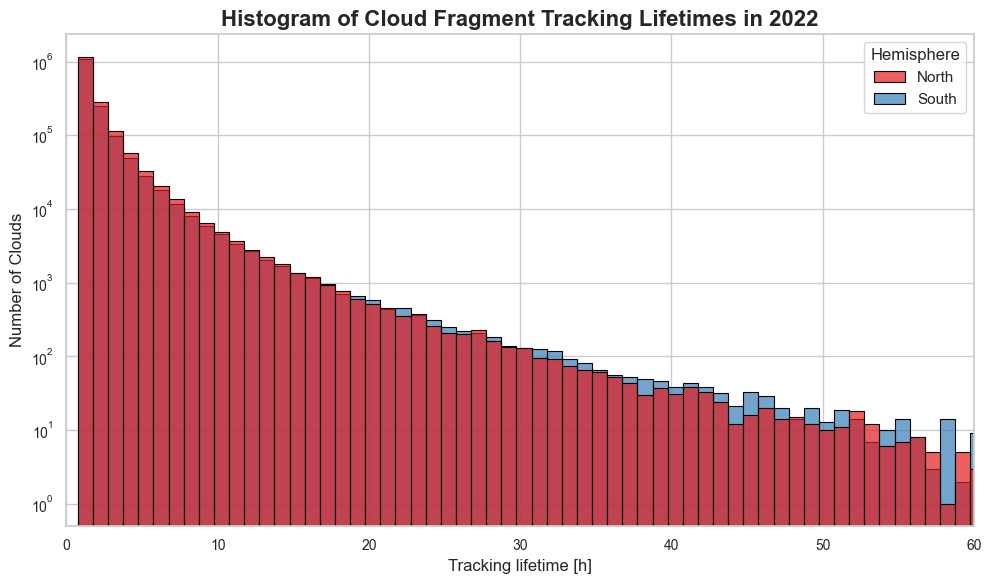

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the contrasting palette with the two specified viridis_colors


plt.figure(figsize=(10, 6))

sns.histplot(data=combined_cloud_df,
             x="Lifetime [h]",
             hue='Hemisphere',
             palette=classifiacation_palette,
             binwidth=1,
             log_scale=[False, True],
             edgecolor='black',
             linewidth=0.8,
             alpha=0.7)

plt.xlabel("Tracking lifetime [h]", fontsize=12)
plt.ylabel("Number of Clouds", fontsize=12)
plt.title("Histogram of Cloud Fragment Tracking Lifetimes in 2022", fontsize=16, fontweight='bold')

plt.yscale('log')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.xlim(0,60)
filename = os.path.join(GTE_DIR, "Result_graphs/lifetime_hist_by_pole")
plt.savefig(filename + '.png', dpi=400, bbox_inches='tight')
plt.savefig(filename + '.pdf', dpi=400, bbox_inches='tight')

plt.show()



Ice containing clouds number histogram

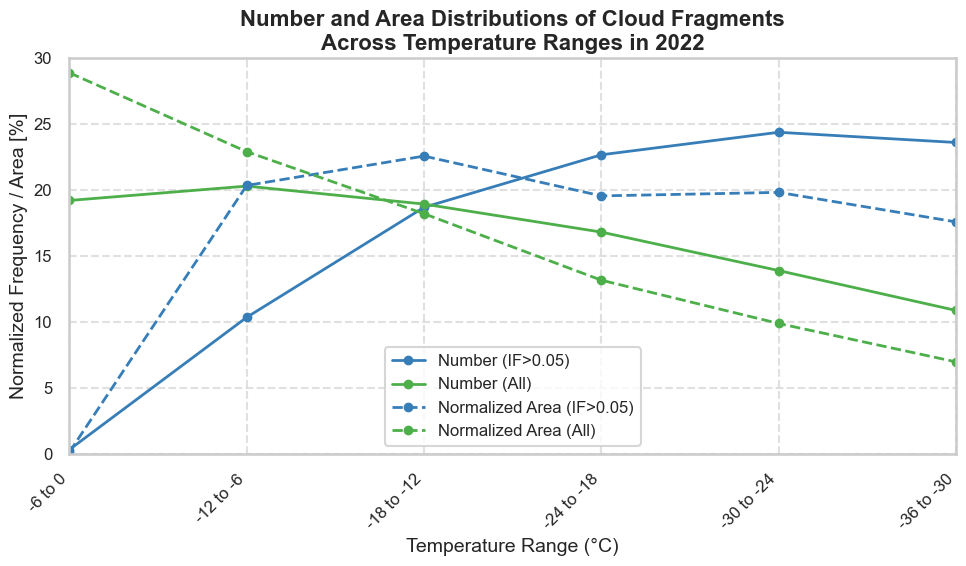

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create labels for the x-axis (temperature ranges)
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]

# Prepare the data arrays
combined_cloud_df["norm_area"] = combined_cloud_df["avg_size[km]"] * combined_cloud_df["Lifetime [h]"]
ice_mask = combined_cloud_df['max_ice_fraction'] > ice_cont_crit_frac
ice_data = combined_cloud_df[ice_mask]['min_temp'].value_counts(sort=False, normalize=True).to_numpy()
ice_area = combined_cloud_df[ice_mask].groupby('min_temp')["norm_area"].sum().iloc[::-1]
ice_area=ice_area/ice_area.sum()
all_data = combined_cloud_df['min_temp'].value_counts(sort=False, normalize=True).to_numpy()
all_area = combined_cloud_df.groupby('min_temp')["norm_area"].sum().iloc[::-1]
all_area=all_area/all_area.sum()
# Set a clean seaborn style and context for improved readability
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10, 6))

# Plot with markers and thicker lines for clarity while preserving the colors

plt.plot(labels, ice_data*100, 
             color=classifiacation_palette[1], label="Number (IF>0.05)",
             marker='o',markersize=6, linewidth=2)
plt.plot(labels, all_data*100, 
             color=classifiacation_palette[2], label="Number (All)",
             marker='o',markersize=6,linewidth=2)
ax_1 = plt.plot(labels, ice_area*100, 
             color=classifiacation_palette[1], label="Normalized Area (IF>0.05)",
             marker='o', linewidth=2,markersize=6, linestyle="--"),# dashes=True, alpha=0.7)
ax_2 = plt.plot(labels, all_area*100, 
             color=classifiacation_palette[2], label="Normalized Area (All)",
             marker='o', linewidth=2,markersize=6, linestyle="--")#,dashes=True, alpha=0.7)

# Add title and axis labels with improved font sizing
plt.title('Number and Area Distributions of Cloud Fragments\nAcross Temperature Ranges in 2022', 
          fontsize=16, fontweight='bold')
plt.xlabel('Temperature Range (°C)', fontsize=14)
plt.ylabel('Normalized Frequency / Area [%]', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(fontsize=12,rotation=45, ha='right')
plt.yticks(fontsize=12)

# Customize gridlines (y-axis only) for a cleaner look
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(True, linestyle="--", alpha=0.6) 
plt.ylim(0,30)
plt.xlim(0,5)
# Optionally, if you prefer y-axis in percentages:
# from matplotlib.ticker import PercentFormatter
# plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# Customize the legend for clarity
plt.legend( fontsize=12, title_fontsize=13, 
           frameon=True, loc='lower center')
ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_visible(False)
# Adjust layout and save the figure with high resolution
plt.tight_layout()
plt.savefig(os.path.join(GTE_DIR, 'Result_graphs/number_and_area_vs_temp_dist.png'), dpi=400, bbox_inches='tight')
plt.show()

Concentration of ice at different temperatures

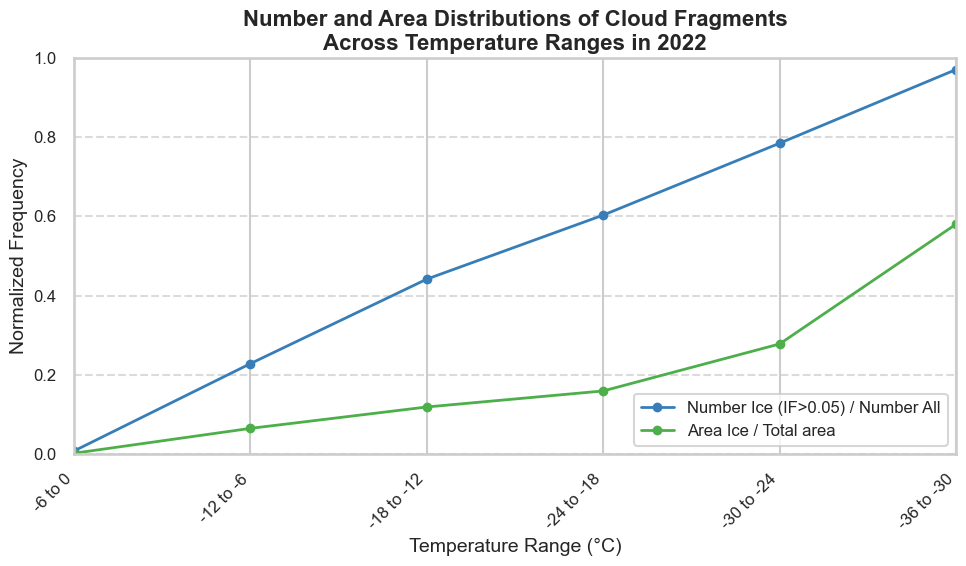

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create labels for the x-axis (temperature ranges)
labels = [f'{config["min_temp_arr"][i]} to {config["max_temp_arr"][i]}' 
          for i in range(len(config["min_temp_arr"]))]
combined_cloud_df["ice_area"]=combined_cloud_df["norm_area"]*(combined_cloud_df["max_ice_fraction"])
# Prepare the data arrays
ice_mask = combined_cloud_df['max_ice_fraction'] > ice_cont_crit_frac
ice_data = combined_cloud_df[ice_mask]['min_temp'].value_counts(sort=False)
ice_area = combined_cloud_df.groupby('min_temp')["ice_area"].sum().iloc[::-1]
all_data = combined_cloud_df['min_temp'].value_counts(sort=False)
all_area = combined_cloud_df.groupby('min_temp')["norm_area"].sum().iloc[::-1]
# Set a clean seaborn style and context for improved readability
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10, 6))

# Plot with markers and thicker lines for clarity while preserving the colors

plt.plot(labels, (ice_data/all_data), 
             color=classifiacation_palette[1], label="Number Ice (IF>0.05) / Number All",
             marker='o', markersize=6, linewidth=2)
plt.plot(labels, ice_area/all_area, 
             color=classifiacation_palette[2], label="Area Ice / Total area",
             marker='o', markersize=6, linewidth=2)
# ax_1 = sns.lineplot(x=labels, y=ice_area, 
#              color=classifiacation_palette[1], label="Avg Istantenious Cover (IF>0.05)",
#              marker='o', markersize=4, linewidth=2, dashes=True, alpha=0.7)
# ax_2 = sns.lineplot(x=labels, y=all_area, 
#              color=classifiacation_palette[2], label="Avg Istantenious Cover (All)",
#              marker='s', markersize=4, linewidth=2,dashes=True, alpha=0.7)
# ax_1.lines[2].set_linestyle("--")
# ax_2.lines[3].set_linestyle("--")

# Add title and axis labels with improved font sizing
plt.title('Number and Area Distributions of Cloud Fragments\nAcross Temperature Ranges in 2022', 
          fontsize=16, fontweight='bold')
plt.xlabel('Temperature Range (°C)', fontsize=14)
plt.ylabel('Normalized Frequency', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(fontsize=12,rotation=45, ha='right')
plt.yticks(fontsize=12)

# Customize gridlines (y-axis only) for a cleaner look
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0,1)
plt.xlim(0,5)
# Optionally, if you prefer y-axis in percentages:
# from matplotlib.ticker import PercentFormatter
# plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# Customize the legend for clarity
plt.legend( fontsize=12, title_fontsize=13, 
           frameon=True, loc='lower right')

# Adjust layout and save the figure with high resolution
plt.tight_layout()
# plt.savefig(os.path.join(GTE_DIR, 'Result_graphs/number_and_area_vs_temp_dist.png'), dpi=400)
plt.show()